<a href="https://colab.research.google.com/github/truesrini/era-v5-s13-reversible/blob/colab-runs/reversible_llm_colab_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reversible transformers on a Colab or Kaggle GPU

**ERA V5, Session 13 assignment.** Train a ~20M-parameter LLM for 50M tokens at a fixed batch size, train it again
with a reversible layer stack (reporting which variant works: midpoint, Euler, ...), then train the reversible model
again at the largest batch that fits. Report final loss, speed (tokens/s), peak memory and other findings.

This is the cloud edition of `reversible_llm.ipynb`, for Google Colab or Kaggle. It runs the same `revlm.py` and the same run plan, with three
differences, all of them forced by the runtime being temporary:

1. **State lives in Google Drive.** `results/`, `checkpoints/` and the tokenized `data/` are mirrored to
   `MyDrive/era-v5-s13/` by a background thread (`colab_env.py`), and copied back down when a new runtime starts.
2. **Every run is resumable.** Training checkpoints itself every few hundred steps. If Colab disconnects,
   reopen this notebook and run every cell again: finished runs replay their saved logs, the run that was
   interrupted continues from its last checkpoint, and nothing is retrained.
3. **The precision is measured, not assumed.** The laptop runs used fp32 because the GTX 1660 Ti has no tensor
   cores; a Colab GPU does, so section 2 measures fp32, fp16 and bf16 on *this* GPU and trains in whichever wins.

| | |
|---|---|
| model | GPT, 10 layers, width 384, 6 heads, context 512, learned positions, tied embeddings, **21.05M parameters** |
| data | TinyStories (one 249 MB training shard, 117M tokens; validation split 4.7M tokens) |
| tokenizer | byte-level BPE, vocab 8,192, trained here on 200k stories |
| optimizer | AdamW (0.9, 0.95), peak lr 1e-3, 2% warmup, cosine to 10%, grad clip 1.0 |
| regularization | dropout 0 and weight decay 0 in every run (reversibility needs a deterministic forward pass) |
| loss | cross-entropy computed in chunks of 2,048 tokens in every run, so the 8,192-wide logits never dominate memory |

**Kaggle (runs with the browser closed):** Settings > Accelerator > GPU T4 x2 (or P100), Settings > Internet > On,
then Save Version > Save & Run All (Commit). Kaggle keeps state in `/kaggle/working/era-v5-s13` instead of Drive.

**Colab:** Runtime > Change runtime type > GPU, then Run all; the first cell asks for Google Drive access.

## 0. Runtime, repository and Drive

Clones the repo onto the runtime's local disk, mounts Drive, copies down whatever earlier sessions left there,
and starts the background upload. Safe to re-run: the clone becomes a `git pull`, and the restore only copies
files that differ.

In [2]:
REPO_URL = "https://github.com/truesrini/era-v5-s13-reversible"
BRANCH = "colab-runs"   # the branch this notebook lives on; falls back to main once that is merged and deleted
import os, subprocess, sys
ON_KAGGLE = os.path.isdir("/kaggle/working")
# The code checkout is scratch; on Kaggle it stays out of /kaggle/working so it is not saved as output.
WORK = "/kaggle/temp/era-v5-s13-reversible" if ON_KAGGLE else "/content/era-v5-s13-reversible"
DRIVE_DIR = "/content/drive/MyDrive/era-v5-s13"   # Colab: everything that must survive a disconnect
                                                  # (Kaggle: /kaggle/working/era-v5-s13 is used instead)
def git(*args):
    r = subprocess.run(["git", *args], capture_output=True, text=True)
    if r.returncode:
        print(r.stderr.strip())
    return r.returncode == 0

if not os.path.isdir(os.path.join(WORK, ".git")):
    git("clone", REPO_URL, WORK)
# Check out BRANCH even if an earlier run of this cell cloned main; untracked data/results/checkpoints are kept.
for b in (BRANCH, "main"):
    if git("-C", WORK, "fetch", "origin", b):
        git("-C", WORK, "checkout", "-q", "-B", b, "FETCH_HEAD")
        break
os.chdir(WORK)
sys.path.insert(0, WORK)
print("cwd:", os.getcwd(), "|", subprocess.run(["git", "log", "-1", "--oneline", "--decorate"], capture_output=True, text=True).stdout.strip())
assert os.path.exists("colab_env.py"), f"colab_env.py missing from {WORK}: delete that folder and re-run this cell"

import importlib, colab_env
importlib.reload(colab_env)   # pick up a newer colab_env.py after a pull without restarting
colab_env.mount(DRIVE_DIR)
colab_env.restore()          # Drive (or Kaggle output) -> local disk (data, finished runs, resume checkpoints)
colab_env.start_sync()       # local disk -> Drive, every 120 s, in the background


cwd: /content/era-v5-s13-reversible | ee2c688 (HEAD -> colab-runs, origin/colab-runs) README: point at the executed results notebook
Mounted at /content/drive
[drive] /content/drive/MyDrive/era-v5-s13
[drive] restored  3 file(s) into data/: tokenizer.json, train.bin, val.bin
[drive] restored 15 file(s) into results/: euler_b16.json, euler_b16.log, euler_b16_5M.json, euler_b16_5M.log, loss_curves.png, max_batch.json, memory.png, midpoint_b16_5M.json, midpoint_b16_5M.log, rev_maxbatch.log, rev_maxbatch_midpoint.json, rev_maxbatch_midpoint.log, standard_b16.json, standard_b16.log, summary.csv
[drive] restored 11 file(s) into checkpoints/: euler_b16.pt, euler_b16_5M.pt, euler_b16_5M_resume.pt, euler_b16_resume.pt, midpoint_b16_5M.pt, midpoint_b16_5M_resume.pt, rev_maxbatch_midpoint.pt, rev_maxbatch_midpoint_resume.pt, rev_maxbatch_resume.pt, standard_b16.pt, standard_b16_resume.pt
[drive] runs already finished: euler_b16, euler_b16_5M, midpoint_b16_5M, rev_maxbatch_midpoint, standard_b16
[

<Thread(drive-sync, started daemon 132766260086464)>

In [ ]:
import json, os, platform, time
import numpy as np, torch
import matplotlib.pyplot as plt
import revlm
from revlm import GPT, probe, max_batch, run_or_load

print("python", platform.python_version(), "| torch", torch.__version__, "| CUDA", torch.version.cuda)
p = torch.cuda.get_device_properties(0)
print(f"GPU: {p.name}, {p.total_memory / 2**30:.2f} GiB, {p.multi_processor_count} SMs, compute {p.major}.{p.minor}")
print("GPU state now:", revlm.gpu_state())
if platform.system() == "Windows":   # the laptop needed an allocator cap; Linux raises a real OOM already
    print(f"PyTorch allocator capped at {revlm.limit_to_dedicated_vram():,.0f} MiB of dedicated VRAM")

## 1. Data

`prep_data.py` downloads TinyStories from the Hugging Face hub, trains the tokenizer and writes `data/train.bin`
and `data/val.bin` as `uint16` token ids. It skips the work when the files already exist -- and after the first
Colab session they do, because the three files were uploaded to Drive and copied back down above. Expect ~6 minutes
the first time and a few seconds after that.

In [ ]:
import prep_data
prep_data.main()
colab_env.sync_now()         # push train.bin / val.bin / tokenizer.json to Drive so this is a one-off cost

from tokenizers import Tokenizer
tok = Tokenizer.from_file("data/tokenizer.json")
val = np.memmap("data/val.bin", dtype=np.uint16, mode="r")
print("\nsample of the validation stream:\n", tok.decode(val[:120].tolist()))

## 2. Which precision is faster on this GPU

The laptop trained in fp32: the GTX 1660 Ti (Turing TU116) has no tensor cores and its fp16 matmuls measured
0.46 TFLOPS against 4.1 TFLOPS in fp32. Colab's GPUs all have tensor cores, so the answer should flip -- but it is
measured here rather than assumed, with real training steps rather than bare matmuls, because the reversible stack
runs every block twice per step and could react differently from the standard one.

In [ ]:
best_precision, prec_table = colab_env.choose_precision(variants=("standard", "euler"), batch=8)

A reversible stack in mixed precision is only safe if the backward pass can still rebuild each layer's input
accurately. The residual states are kept in fp32 inside `revlm.py` even when the matmuls are not, so the
reconstruction error should stay small; this checks it on the chosen precision and falls back to fp32 if it does not.

In [ ]:
rec = {}
for v, h in [("euler", 1.0), ("midpoint", 0.5)]:
    m = GPT(variant=v, h=h).cuda()
    x, _ = revlm.Tokens("val").batch(4, 512, torch.Generator().manual_seed(7))
    rec[v] = revlm.reconstruction_error(m, x)
    print(f"{v:9s} reconstruction relative error in {best_precision}: {rec[v]:.2e}")
    del m; torch.cuda.empty_cache()

if max(rec.values()) > 1e-3 and revlm.AMP:
    revlm.AMP = False
    print(f"\n-> reconstruction error too large in {best_precision}; falling back to fp32 for the training runs")
    best_precision = "fp32"
else:
    print(f"\n-> keeping {best_precision}: the reversible stack reconstructs its inputs to "
          f"{max(rec.values()):.0e} relative error")

## 3. The reversible stack

Write $p^\ell$ for the residual stream entering layer $\ell$ and $f_\ell(p) = \mathrm{Attn}_\ell(\mathrm{LN}_1 p) + \mathrm{MLP}_\ell(\mathrm{LN}_2(p + \mathrm{Attn}_\ell(\mathrm{LN}_1 p)))$
for the whole block (Gal et al. 2025, *Reversing Large Language Models for Efficient Training and Fine-Tuning*, Eq. 5).
`revlm.py` implements four reversible rules:

| variant | forward | inverse (used in the backward pass) |
|---|---|---|
| **midpoint** (Eq. 4) | $p^{\ell+1} = p^{\ell-1} + 2h\,f_\ell(p^\ell)$ | $p^{\ell-1} = p^{\ell+1} - 2h\,f_\ell(p^\ell)$ |
| **Euler** (symplectic / Hamiltonian, Eqs. 8-9, $a=b=1$) | $q^{\ell+1} = q^\ell + h\,\mathrm{Attn}(\mathrm{LN}_1 p^\ell)$; $p^{\ell+1} = p^\ell + h\,\mathrm{MLP}(\mathrm{LN}_2 q^{\ell+1})$ | $p^\ell = p^{\ell+1} - h\,\mathrm{MLP}(\cdot)$; $q^\ell = q^{\ell+1} - h\,\mathrm{Attn}(\cdot)$ |
| **leapfrog** (Eq. 6) | $p^{\ell+1} = 2p^\ell - p^{\ell-1} + h^2 f_\ell(p^\ell)$ | $p^{\ell-1} = 2p^\ell - p^{\ell+1} + h^2 f_\ell(p^\ell)$ |
| **blend**, "midpoint (a)" (Eq. 15, fixed $a$) | $p^{\ell+1} = a\,p^{\ell-1} + (1-a)\,p^\ell + h\,f_\ell(p^\ell)$ | $p^{\ell-1} = (p^{\ell+1} - (1-a)p^\ell - h f_\ell(p^\ell))/a$ |

Both streams start at the embedding ($p^{-1} = p^0$, or $q^0 = p^0$), and the head reads the last state through a final
LayerNorm. The whole stack is one `torch.autograd.Function`: the forward pass runs under `no_grad` and keeps only the
final pair of states; the backward pass walks the layers in reverse, rebuilds each layer's input from its output with
the inverse rule, and runs that layer once more with autograd on to get its gradients. Each block is therefore
evaluated twice per step (forward, and once in the backward pass), against once for the standard stack.

**Correctness check.** In float64 the reversible backward pass must give the same gradients as ordinary autograd
applied to the same update rule:

In [ ]:
import check_grads
check_grads.main()

## 4. Memory and speed probes

A few training steps per configuration, measuring `torch.cuda.max_memory_allocated` and step time.
`checkpoint` is ordinary activation recomputation (stores each block's input, re-runs the block in the backward
pass), included as the alternative the session notes compare against.

Unlike the laptop, a Colab GPU is datacentre-cooled and does not thermally throttle, so these probes are far less
noisy than the laptop's were -- the throughput numbers below should match what the long runs sustain.

In [ ]:
rows = []
for v in ["standard", "checkpoint", "euler", "midpoint"]:
    for b in [8, 16, 32, 64]:
        r = probe(v, b, steps=6, h=0.5 if v == "midpoint" else 1.0)
        rows.append((v, b, r))
        print(f"{v:10s} batch {b:3d}: " + (f"peak {r['peak_mib']:7,.0f} MiB  {r['tok_s']:8,.0f} tok/s" if r else "OOM"), flush=True)

**Memory against depth.** The reversible stack's activation memory should not grow with the number of layers.
Batch 8 x 512 tokens, width 384, depth 10 to 80. The training state (fp32 weight, gradient and two Adam moments,
16 bytes per parameter) grows with depth in every variant, so the split below separates it from the rest:

In [ ]:
depth = {}
for v in ["standard", "checkpoint", "euler"]:
    for L in [10, 20, 40, 80]:
        r = probe(v, 8, steps=2, n_layer=L)
        depth[(v, L)] = r
        print(f"{v:10s} {L:3d} layers: " + (f"peak {r['peak_mib']:7,.0f} MiB = training state {r['state_mib']:6,.0f} "
              f"+ activations/workspace {r['act_mib']:6,.0f} MiB" if r else "OOM"), flush=True)

**Largest batch that fits** (doubling, then a binary search; batch = sequences of 512 tokens). This takes a few
minutes and is cached in `results/max_batch.json`, so a later session reuses the first measurement instead of
re-probing. On a 15 GB T4 the reversible limit is large enough that the probe's own 4096 ceiling can be the binding
constraint rather than memory; the cell says so when that happens.

In [ ]:
os.makedirs("results", exist_ok=True)
if os.path.exists("results/max_batch.json"):
    mb = json.load(open("results/max_batch.json"))
    print("(loaded from results/max_batch.json, measured in an earlier session)")
else:
    mb = {}
    for v in ["standard", "checkpoint", "euler", "midpoint"]:
        t = time.time()
        mb[v] = max_batch(v, start=16, limit=4096, h=0.5 if v == "midpoint" else 1.0)
        print(f"{v:10s} probed in {time.time() - t:.0f}s", flush=True)
    json.dump(mb, open("results/max_batch.json", "w"), indent=1)
    colab_env.sync_now()
for v, b in mb.items():
    print(f"{v:10s} max batch {b:4d}  ({b * 512:,} tokens/step)"
          + ("   <- hit the probe's 4096 ceiling, not the GPU's" if b >= 4096 else ""))

## 5. What fits in one Colab session

`QUICK = True` (the default) fits a ~2 hour session: three 50M-token runs (standard, Euler, and reversible at max
batch), with Euler and midpoint compared on equal 5M-token screens to pick the variant for the max-batch run.
`QUICK = False` is the full plan: midpoint also gets a full 50M-token run, plus 5M screens of leapfrog and blend
(about an hour more). The estimate below comes from the throughput just measured, so it
tells you before you start whether this session can finish everything or whether you will be resuming. Nothing is
lost either way: every run checkpoints to Drive, so you can close the tab and re-run this notebook later.

In [ ]:
QUICK = True   # False: also a full 50M midpoint run and the leapfrog/blend screens (~1 h more)
FIXED = dict(batch=16, tokens=50_000_000, log_every=100, eval_every=500, ckpt_every=500)
SCREEN = dict(batch=16, tokens=5_000_000, log_every=50, eval_every=200, ckpt_every=200)

plan = [("standard_b16", "standard", 16, 50), ("euler_b16", "euler", 16, 50)]
plan += ([("euler_b16_5M", "euler", 16, 5), ("midpoint_b16_5M", "midpoint", 16, 5)] if QUICK else
         [("midpoint_b16", "midpoint", 16, 50), ("leapfrog_b16_5M", "midpoint", 16, 5), ("blend_b16_5M", "midpoint", 16, 5)])
plan += [("rev_maxbatch", "euler", min(mb.get("euler", 16), 4096), 50)]
tps = {v: next((r["tok_s"] for vv, b, r in rows if vv == v and b == 16 and r), None) for v in
       ["standard", "checkpoint", "euler", "midpoint"]}
total = 0.0
for name, variant, batch, mtok in plan:
    done = os.path.exists(f"results/{name}.json")
    mins = mtok * 1e6 / tps[variant] / 60 if tps.get(variant) else float("nan")
    total += 0 if done else mins
    print(f"{name:18s} {mtok:3d}M tokens, batch {batch:4d}  ~{mins:5.0f} min" + ("   (already finished)" if done else ""))
print(f"\nplan: {'QUICK' if QUICK else 'full'} | remaining: ~{total / 60:.1f} h of training (plus a few minutes of evals). "
      "A free Colab session is capped near 4 h.")


## 6. Run 1: standard transformer, fixed batch 16 x 512 = 8,192 tokens/step

6,103 steps for 50M tokens. Batch 16 is the fixed batch for the first two sections of the assignment, kept the same
as the laptop runs so the three numbers reported for it are comparable across machines.

Each of the four `run_or_load` cells below does one of three things: trains the run, resumes it from its last
checkpoint, or replays the log of a run that already finished. The live log is also in `results/<run>.log` on Drive,
so you can watch progress from your phone while the tab is closed.

In [ ]:
res = {}
res["standard_b16"] = run_or_load(name="standard_b16", variant="standard", **FIXED)
colab_env.sync_now()

## 7. Run 2: reversible, same batch 16

Euler with $h = 1$ (each half-step adds a full attention or MLP update, like a standard residual block) for the full
50M tokens. Midpoint uses $h = 0.5$ (so $2h = 1$ and each update has the same scale); with `QUICK = True` it is
compared against Euler on two identical 5M-token screens (same data order, same compressed learning-rate schedule)
rather than with a second full run.


In [ ]:
res["euler_b16"] = run_or_load(name="euler_b16", variant="euler", h=1.0, **FIXED)
colab_env.sync_now()

In [ ]:
if QUICK:
    for v, h in [("euler", 1.0), ("midpoint", 0.5)]:
        res[f"{v}_b16_5M"] = run_or_load(name=f"{v}_b16_5M", variant=v, h=h, **SCREEN)
else:
    res["midpoint_b16"] = run_or_load(name="midpoint_b16", variant="midpoint", h=0.5, **FIXED)
colab_env.sync_now()


**Short screens of the other two rules** (`QUICK = False` only) (5M tokens each, same batch, same learning-rate shape compressed to 5M
tokens): leapfrog with $h = 1$, and the blend rule with the Lightning LM settings, $h = 0.25$, $a = 0.5$.

In [ ]:
if not QUICK:
    res["leapfrog_b16_5M"] = run_or_load(name="leapfrog_b16_5M", variant="leapfrog", h=1.0, **SCREEN)
    res["blend_b16_5M"] = run_or_load(name="blend_b16_5M", variant="blend", h=0.25, alpha=0.5, **SCREEN)
    colab_env.sync_now()
else:
    print("QUICK plan: leapfrog and blend screens skipped")


In [ ]:
sfx = "_b16_5M" if QUICK else "_b16"
for v in ["euler", "midpoint"]:
    r = res[f"{v}{sfx}"]
    print(f"{v}{sfx:8s} final val loss {r['final_val_loss']:.4f}  train {r['final_train_loss']:.4f}  {r['tok_per_s']:,.0f} tok/s  "
          f"peak {r['peak_alloc_mib']:,.0f} MiB  reconstruction rel err {r['reconstruction_rel_err']:.1e}")
# Prefer Euler unless midpoint wins clearly. A first Colab run picked midpoint on a 0.02 margin at 5M tokens, and at the
# max batch (lr 3e-3) midpoint stopped being invertible (reconstruction error 0.32), so its gradients were wrong.
margin = res[f"euler{sfx}"]["final_val_loss"] - res[f"midpoint{sfx}"]["final_val_loss"]
best = "midpoint" if margin > 0.05 else "euler"
print(f"-> variant used for the max-batch run: {best} (midpoint must beat Euler by more than 0.05; margin {margin:+.3f})")


## 8. Run 3: reversible at the maximum batch size

The batch is the probed maximum for the chosen variant, less 10% so that allocator fragmentation over a long run
cannot push it out of memory. The token budget stays at 50M, so a larger batch means fewer optimizer steps; the peak
learning rate is scaled by $\sqrt{B/16}$ (capped at 3e-3) and warmup is 5% of the steps.

In [ ]:
B = int(mb[best] * 0.9)
lr = min(3e-3, 1e-3 * (B / 16) ** 0.5)
steps = 50_000_000 // (B * 512)
print(f"{best}: probed max batch {mb[best]}, training at batch {B} ({B * 512:,} tokens/step, {steps} steps), lr {lr:.2e}")
res["rev_maxbatch"] = run_or_load(name="rev_maxbatch", variant=best, h=1.0 if best == "euler" else 0.5, batch=B,
                                  lr=lr, warmup_frac=0.05, tokens=50_000_000,
                                  log_every=max(5, steps // 60), eval_every=max(10, steps // 12),
                                  ckpt_every=max(10, steps // 12))
colab_env.sync_now()

## 9. Results

In [ ]:
import pandas as pd
order = ["standard_b16", "euler_b16", "midpoint_b16", "rev_maxbatch", "euler_b16_5M", "midpoint_b16_5M",
         "leapfrog_b16_5M", "blend_b16_5M"]
tab = pd.DataFrame([{
    "run": k, "variant": res[k]["cfg"]["variant"], "batch": res[k]["cfg"]["batch"],
    "precision": res[k].get("precision", "fp32"), "gpu": res[k].get("gpu", "?").replace("NVIDIA ", ""),
    "tokens (M)": round(res[k]["tokens_seen"] / 1e6, 1), "steps": res[k]["steps"],
    "final train loss": round(res[k]["final_train_loss"], 4), "final val loss": round(res[k]["final_val_loss"], 4),
    "tokens/s": round(res[k]["tok_per_s"]), "peak alloc (MiB)": round(res[k]["peak_alloc_mib"]),
    "peak reserved (MiB)": round(res[k]["peak_reserved_mib"]), "train time (min)": round(res[k]["train_minutes"], 1),
    "reconstruction rel err": (f"{res[k]['reconstruction_rel_err']:.1e}" if "reconstruction_rel_err" in res[k] else "-"),
} for k in order if k in res]).set_index("run")
tab.to_csv("results/summary.csv")
gpus = set(tab["gpu"])
if len(gpus) > 1:
    print(f"WARNING: these runs were not all trained on the same GPU ({', '.join(sorted(gpus))}). "
          "Losses are still comparable; tokens/s and peak memory are not.\n")
tab

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
for k in [k for k in ["standard_b16", "euler_b16", "midpoint_b16", "rev_maxbatch"] if k in res]:
    h, c = res[k]["hist"], res[k]["cfg"]
    mtok = np.array(h["step"]) * c["batch"] * c["ctx"] / 1e6
    ax[0].plot(mtok, h["loss"], label=k)
    ax[1].plot(np.array(h["val_step"]) * c["batch"] * c["ctx"] / 1e6, h["val_loss"], "o-", ms=3, label=k)
    ax[2].plot(mtok, np.array(h["tok_s"]) / 1e3, label=k, lw=0.8)
ax[0].set(title="train loss", xlabel="tokens (M)", ylim=(1.0, 4.0))
ax[1].set(title="validation loss", xlabel="tokens (M)", ylim=(1.0, 4.0))
ax[2].set(title="throughput", xlabel="tokens (M)", ylabel="k tokens/s")
for a in ax: a.grid(alpha=0.3); a.legend()
plt.tight_layout(); plt.savefig("results/loss_curves.png", dpi=120); plt.show()

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
for v in ["standard", "checkpoint", "euler", "midpoint"]:
    pts = [(b, r["peak_mib"]) for vv, b, r in rows if vv == v and r]
    ax[0].plot(*zip(*pts), "o-", label=v)
ax[0].set(title="peak memory vs batch (10 layers)", xlabel="batch (x512 tokens)", ylabel="MiB")
for v in ["standard", "checkpoint", "euler"]:
    pts = [(L, r["act_mib"]) for (vv, L), r in depth.items() if vv == v and r]
    ax[1].plot(*zip(*pts), "o-", label=v)
ax[1].set(title="peak minus training state vs depth (batch 8)", xlabel="layers", ylabel="MiB")
ks = [k for k in ["standard_b16", "euler_b16", "midpoint_b16", "rev_maxbatch"] if k in res]
ax[2].bar(ks, [res[k]["peak_alloc_mib"] for k in ks], color=[f"C{i}" for i in range(len(ks))])
ax[2].set(title="peak memory of the full runs", ylabel="MiB")
ax[2].tick_params(axis="x", rotation=15)
for a in ax[:2]: a.grid(alpha=0.3); a.legend()
plt.tight_layout(); plt.savefig("results/memory.png", dpi=120); plt.show()

In [ ]:
# Text samples from the final weights of each 50M-token run (checkpoints/ is kept out of git)
for k in [k for k in ["standard_b16", "euler_b16", "midpoint_b16", "rev_maxbatch"] if k in res]:
    c = res[k]["cfg"]
    m = GPT(variant=c["variant"], h=c["h"], alpha=c["alpha"]).cuda()
    m.load_state_dict(torch.load(f"checkpoints/{k}.pt"))
    print("---", k)
    print(revlm.generate(m, tok, "Once upon a time, a little dog named Max"))
    print()
    del m

## 10. Findings

_(written after the runs finish)_

In [ ]:
colab_env.sync_now()
colab_env.sync_report()
print("\nEverything is in", DRIVE_DIR, "- results/, checkpoints/ and data/ survive this runtime.")

### Results from T4 runs


===== euler_b16 =====
[euler_b16] variant=euler h=1.0 alpha=0.5 params=21.05M batch=16x512=8192 tokens/step steps=6103 tokens=50.0M lr=0.001 precision=fp32 Tesla T4
step   100/6103 | loss 5.7318 | lr 8.20e-04 | 14,142 tok/s | peak 649 MiB | 0.8M tok | 1.0 min | gpu 76C 1065/5000MHz
step   200/6103 | loss 3.9790 | lr 1.00e-03 | 14,163 tok/s | peak 649 MiB | 1.6M tok | 1.9 min | gpu 76C 795/5000MHz
step   300/6103 | loss 3.7107 | lr 9.98e-04 | 14,176 tok/s | peak 649 MiB | 2.5M tok | 2.9 min | gpu 76C 750/5000MHz
step   400/6103 | loss 3.4495 | lr 9.95e-04 | 14,140 tok/s | peak 649 MiB | 3.3M tok | 3.9 min | gpu 76C 1080/5000MHz
step   500/6103 | loss 3.2512 | lr 9.91e-04 | 14,092 tok/s | peak 649 MiB | 4.1M tok | 4.8 min | gpu 76C 1050/5000MHz | val 3.1716
step   600/6103 | loss 3.1007 | lr 9.86e-04 | 14,095 tok/s | peak 649 MiB | 4.9M tok | 5.8 min | gpu 76C 1065/5000MHz
step   700/6103 | loss 2.9677 | lr 9.79e-04 | 14,082 tok/s | peak 649 MiB | 5.7M tok | 6.8 min | gpu 77C 1095/5000M

,variant,batch,precision,gpu,tokens (M),steps,final train loss,final val loss,tokens/s,peak alloc (MiB),train time (min),reconstruction rel err
run,,,,,,,,,,,,
euler_b16,euler,16,fp32,Tesla T4,50.0,6103,1.9281,1.9210,14016,649,59.5,1.8e-03
euler_b16_5M,euler,16,fp32,Tesla T4,5.0,610,3.3665,3.2941,14049,649,5.9,6.4e-04
midpoint_b16_5M,midpoint,16,fp32,Tesla T4,5.0,610,3.3534,3.2730,13901,709,6.0,1.6e-03
rev_maxbatch_midpoint,midpoint,518,fp32,Tesla T4,49.9,188,4.6213,4.5968,13635,12394,60.9,3.2e-01
standard_b16,standard,16,fp32,Tesla T4,50.0,6103,1.7879,1.7834,18423,2425,45.2,-


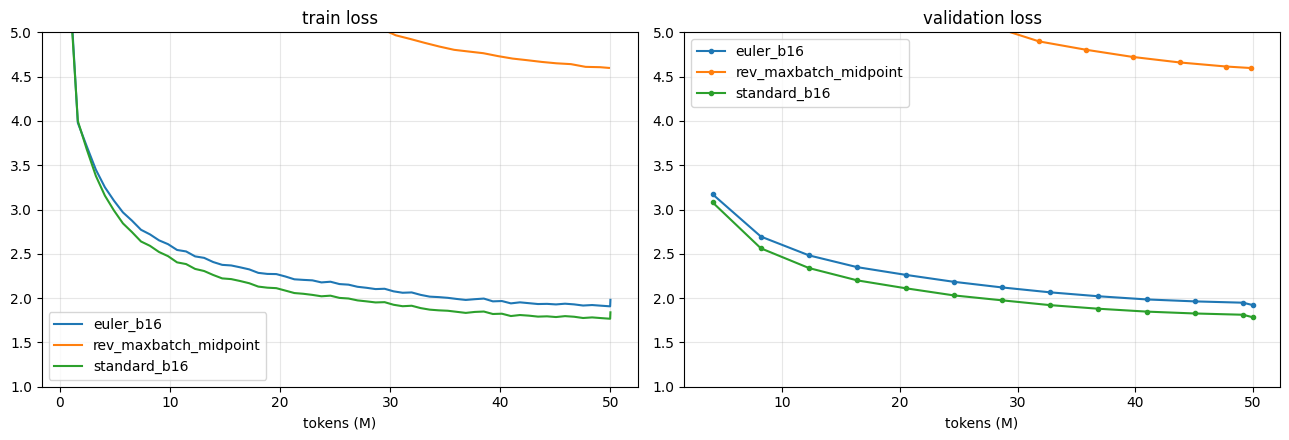

[drive] uploaded 2 file(s): loss_curves.png, summary.csv


['loss_curves.png', 'summary.csv']

In [3]:
import json, os, glob
import pandas as pd, numpy as np, matplotlib.pyplot as plt
res = {os.path.basename(p)[:-5]: json.load(open(p)) for p in sorted(glob.glob("results/*.json"))
       if not p.endswith("max_batch.json")}
for n in res:                                   # the full training logs of every run
    if os.path.exists(f"results/{n}.log"):
        print(f"\n===== {n} =====\n" + open(f"results/{n}.log").read())
tab = pd.DataFrame([{
    "run": k, "variant": r["cfg"]["variant"], "batch": r["cfg"]["batch"], "precision": r.get("precision", "fp32"),
    "gpu": r.get("gpu", "?"), "tokens (M)": round(r["tokens_seen"] / 1e6, 1), "steps": r["steps"],
    "final train loss": round(r["final_train_loss"], 4), "final val loss": round(r["final_val_loss"], 4),
    "tokens/s": round(r["tok_per_s"]), "peak alloc (MiB)": round(r["peak_alloc_mib"]),
    "train time (min)": round(r["train_minutes"], 1),
    "reconstruction rel err": f"{r['reconstruction_rel_err']:.1e}" if "reconstruction_rel_err" in r else "-",
} for k, r in res.items()]).set_index("run")
tab.to_csv("results/summary.csv"); display(tab)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for k, r in res.items():
    if r["tokens_seen"] < 40e6: continue
    h, c = r["hist"], r["cfg"]
    ax[0].plot(np.array(h["step"]) * c["batch"] * c["ctx"] / 1e6, h["loss"], label=k)
    ax[1].plot(np.array(h["val_step"]) * c["batch"] * c["ctx"] / 1e6, h["val_loss"], "o-", ms=3, label=k)
for a, t in zip(ax, ["train loss", "validation loss"]): a.set(title=t, xlabel="tokens (M)", ylim=(1, 5)); a.grid(alpha=.3); a.legend()
plt.tight_layout(); plt.savefig("results/loss_curves.png", dpi=120); plt.show()
colab_env.sync_now()